#Lab Activity 07

A **Recurrent Neural Network (RNN)** processes a *sequence* one element at a
time, carrying a hidden state from one step to the next. That hidden state is
the network's memory: at every step it combines what it has seen so far with the
new input.

$$h_t = \tanh(W h_{t-1} + U x_t) \qquad y_t = \mathrm{softmax}(V h_t)$$

The same weights `W`, `U` and `V` are reused at **every** time step — which is
what makes the network "recurrent", and what lets it handle sequences of any
length. Unrolling an RNN over a 5-word sentence gives something that looks like
a 5-layer network, except that all five layers share one set of weights.

This activity follows the tutorial the manual links to. It has two halves:

1. Pull a Keras `SimpleRNN` apart and **recompute its output by hand**, to see
   exactly what the layer does.
2. Train a `SimpleRNN` to predict a real time series — monthly sunspot counts.

##Activity 1, part 1: What a SimpleRNN actually computes

A tiny network is the easiest place to see the mechanism: **2 hidden units**, an
input sequence of **3 time steps** with **1 feature** each.

`activation='linear'` is used deliberately here. With `tanh` in the way, the
hand calculation would need the non-linearity applied at every step; keeping it
linear makes the arithmetic transparent. The structure being demonstrated is the
same either way.

###Building the demonstration network

In [1]:
import os
# Keep TensorFlow's start-up logging out of the notebook output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import keras
from keras import Sequential
from keras.layers import Input, Dense, SimpleRNN

keras.utils.set_random_seed(42)

demo_model = Sequential([
    Input(shape=(3, 1)),                                    # 3 time steps, 1 feature
    SimpleRNN(2, name="SimpleRNN", activation="linear"),    # 2 hidden units
    Dense(1, activation="linear"),
])

demo_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN (SimpleRNN)           │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

###The three weight matrices

A `SimpleRNN` layer holds exactly three things:

| Weight | Shape | Role |
|---|---|---|
| `wx` (kernel) | (features, units) = (1, 2) | applied to the **input** at the current step |
| `wh` (recurrent kernel) | (units, units) = (2, 2) | applied to the **hidden state** from the previous step |
| `bh` (bias) | (units,) = (2,) | added at every step |

`wh` is the recurrent part — the only reason this layer differs from a `Dense`
one. The `Dense` layer that follows contributes `wy` and `by`.

In [2]:
wx = demo_model.get_weights()[0]
wh = demo_model.get_weights()[1]
bh = demo_model.get_weights()[2]
wy = demo_model.get_weights()[3]
by = demo_model.get_weights()[4]

print("wx (input weights)     shape", wx.shape, "\n", wx)
print("\nwh (recurrent weights) shape", wh.shape, "\n", wh)
print("\nbh (hidden bias)       shape", bh.shape, "\n", bh)
print("\nwy (output weights)    shape", wy.shape, "\n", wy)
print("\nby (output bias)       shape", by.shape, "\n", by)

total = sum(w.size for w in demo_model.get_weights())
print("\nTotal parameters:", total,
      "= (1x2 + 2x2 + 2) for the RNN, + (2x1 + 1) for the Dense layer")

wx (input weights)     shape (1, 2) 
 [[ 1.3552576  -0.05086112]]

wh (recurrent weights) shape (2, 2) 
 [[ 0.06604707 -0.99781656]
 [ 0.99781656  0.06604695]]

bh (hidden bias)       shape (2,) 
 [0. 0.]

wy (output weights)    shape (2, 1) 
 [[0.8936349]
 [0.3859049]]

by (output bias)       shape (1,) 
 [0.]

Total parameters: 11 = (1x2 + 2x2 + 2) for the RNN, + (2x1 + 1) for the Dense layer


###Recomputing the network's answer by hand

Feed the sequence `[1, 2, 3]` through the network, then work the same sequence
through the equations manually.

The hidden state starts at zero. At each step it is the input contribution plus
the previous hidden state passed through the recurrent weights, plus the bias:

```
h1 = x1 . wx  +  h0 . wh  +  bh      (h0 is all zeros)
h2 = x2 . wx  +  h1 . wh  +  bh
h3 = x3 . wx  +  h2 . wh  +  bh
o3 = h3 . wy  +  by
```

Only the **final** hidden state `h3` reaches the output layer, because
`SimpleRNN` returns just its last state unless asked for the whole sequence.

In [3]:
x = np.array([1, 2, 3])
x_input = np.reshape(x, (1, 3, 1))          # (batch, time steps, features)

y_pred_model = demo_model.predict(x_input, verbose=0)

# The same computation, done by hand
m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + h0 + bh
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh
o3 = np.dot(h3, wy) + by

print("h1 =", h1)
print("h2 =", h2)
print("h3 =", h3)
print()
print("Prediction from the network    :", y_pred_model)
print("Prediction from our computation :", o3)
print()
print("Do they agree?", np.allclose(y_pred_model, o3))

h1 = [[ 1.35525763 -0.05086112]]
h2 = [[ 2.74927599 -1.45737997]]
h3 = [[ 2.79315665 -2.99211199]]

Prediction from the network    : [[1.3413916]]
Prediction from our computation : [[1.3413916]]

Do they agree? True


The two match, which confirms the mechanism: **one set of weights, applied
again at every time step, with the hidden state carrying information forward.**

Notice that `h1` depends only on `x1`, but `h3` depends on all three inputs —
`x3` directly, and `x1` and `x2` through the chain of recurrent multiplications.
That chain is exactly where the vanishing gradient problem comes from: the
further back an input is, the more times its influence has been multiplied by
`wh` on the way to the output.

##Activity 1, part 2: Predicting sunspots with a SimpleRNN

The second half of the tutorial trains a `SimpleRNN` on a real time series —
monthly sunspot counts from 1749 onwards, 2820 observations. A copy is saved
next to this notebook so the activity runs offline.

The task is **regression**: given the previous 12 months, predict the next
value.

###Loading and scaling the data

In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline


def get_train_test(path, split_percent=0.8):
    df = pd.read_csv(path, usecols=[1], engine="python")
    data = np.array(df.values.astype("float32"))

    # Scale to 0-1: RNNs train poorly on raw values in the hundreds
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)
    split = int(n * split_percent)
    # A time series is split by TIME, never shuffled - the test set has to be
    # the future relative to the training set
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data


train_data, test_data, data = get_train_test("monthly-sunspots.csv")

print("Total observations:", len(data))
print("Train:", len(train_data), "| Test:", len(test_data))
print("Scaled range: %.3f to %.3f" % (data.min(), data.max()))

Total observations: 2820
Train: 2256 | Test: 564
Scaled range: 0.000 to 1.000


###Turning a series into supervised examples

An RNN needs `(sequence, target)` pairs. `get_XY` walks the series in blocks of
`time_steps`, using each block as the input and the value that follows it as the
target, then reshapes the input to the
**(samples, time steps, features)** layout every Keras recurrent layer expects.

In [5]:
def get_XY(dat, time_steps):
    # Targets: every time_steps-th value
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]

    rows_x = len(Y)
    X = dat[range(time_steps * rows_x)]
    # (samples, time steps, features) - the shape Keras recurrent layers expect
    X = np.reshape(X, (rows_x, time_steps, 1))
    return X, Y


time_steps = 12          # one year of history per prediction
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

print("trainX", trainX.shape, "-> trainY", trainY.shape)
print("testX ", testX.shape, "-> testY ", testY.shape)
print("\nOne training example (12 months of scaled counts):")
print(np.round(trainX[0].flatten(), 3), "-> predict", round(float(trainY[0]), 3))

trainX (187, 12, 1) -> trainY (187,)
testX  (46, 12, 1) -> testY  (46,)

One training example (12 months of scaled counts):
[0.229 0.247 0.276 0.219 0.335 0.329 0.374 0.261 0.299 0.297 0.625 0.336] -> predict 0.289


###Building and training the network

Three hidden units and a single output. `tanh` is used here rather than the
`linear` of part 1 — the manual notes that `tanh` is the usual choice for RNNs
because its second derivative decays slowly to zero, which keeps gradients in
the useful region of the activation function for longer.

The loss is mean squared error, because this is regression rather than
classification.

In [6]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(hidden_units, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1]),
    ])
    model.compile(loss="mean_squared_error", optimizer="adam")
    return model


keras.utils.set_random_seed(42)

model = create_RNN(hidden_units=3, dense_units=1,
                   input_shape=(time_steps, 1),
                   activation=["tanh", "linear"])
model.summary()

history = model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

...

187/187 - 1s - 4ms/step - loss: 0.0043


Epoch 19/20


187/187 - 1s - 6ms/step - loss: 0.0043


Epoch 20/20


187/187 - 1s - 4ms/step - loss: 0.0043


###How well did it do?

In [7]:
def print_error(trainY, testY, train_predict, test_predict):
    train_rmse = np.sqrt(np.mean((train_predict.flatten() - trainY) ** 2))
    test_rmse = np.sqrt(np.mean((test_predict.flatten() - testY) ** 2))
    print("Train RMSE: %.3f" % train_rmse)
    print("Test  RMSE: %.3f" % test_rmse)
    return train_rmse, test_rmse


train_predict = model.predict(trainX, verbose=0)
test_predict = model.predict(testX, verbose=0)

train_rmse, test_rmse = print_error(trainY, testY, train_predict, test_predict)

# Two reference points the RNN ought to beat.
# 1. Persistence: predict that the next value equals the most recent one.
naive_train = np.sqrt(np.mean((trainX[:, -1, 0] - trainY) ** 2))
naive_test = np.sqrt(np.mean((testX[:, -1, 0] - testY) ** 2))
# 2. Predict the training mean every time, ignoring the input completely.
mean_test = np.sqrt(np.mean((trainY.mean() - testY) ** 2))

print()
print("%-34s %8s %8s" % ("", "train", "test"))
print("%-34s %8.3f %8.3f" % ("SimpleRNN", train_rmse, test_rmse))
print("%-34s %8.3f %8.3f" % ("Persistence (next = latest)", naive_train, naive_test))
print("%-34s %8s %8.3f" % ("Always predict the mean", "-", mean_test))

Train RMSE: 0.071
Test  RMSE: 0.107

                                      train     test
SimpleRNN                             0.071    0.107
Persistence (next = latest)           0.063    0.080
Always predict the mean                   -    0.246


###Plotting the predictions

The scaled series with the network's predictions drawn over it. The vertical
line marks where the training data ends and the test data begins — everything to
the right of it is the future as far as the model is concerned.

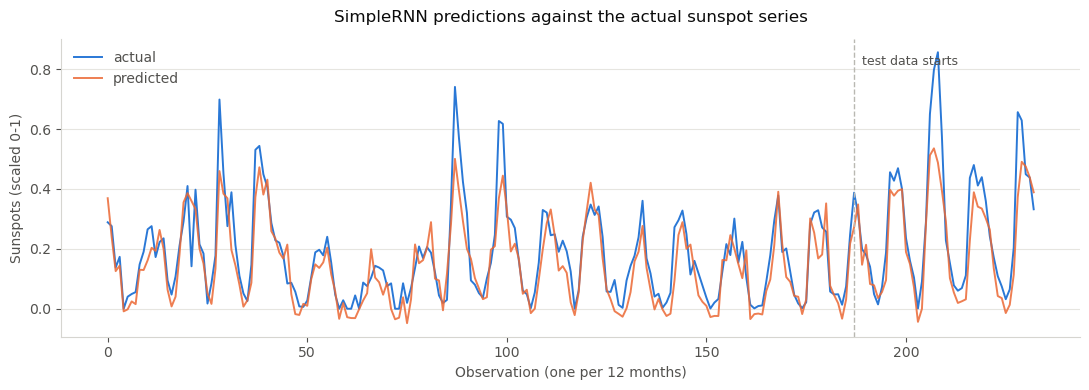

In [8]:
SERIES = "#2a78d6"
PREDICTED = "#eb6834"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

# Place each prediction at the index of the value it was predicting
actual = np.append(trainY, testY)
predictions = np.append(train_predict.flatten(), test_predict.flatten())
rows = len(actual)
split_at = len(trainY)

figure, axes = plt.subplots(figsize=(11, 4))

axes.plot(np.arange(rows), actual, color=SERIES, linewidth=1.4, label="actual")
axes.plot(np.arange(rows), predictions, color=PREDICTED, linewidth=1.4,
          alpha=0.85, label="predicted")
axes.axvline(split_at, color="#b9b8b2", linewidth=1, linestyle="--")
axes.text(split_at + 2, actual.max() * 0.95, "test data starts",
          color=INK_SOFT, fontsize=9)

axes.set_xlabel("Observation (one per %d months)" % time_steps, color=INK_SOFT)
axes.set_ylabel("Sunspots (scaled 0-1)", color=INK_SOFT)
axes.set_title("SimpleRNN predictions against the actual sunspot series",
               color=INK, fontsize=12, pad=12)
axes.legend(frameon=False, labelcolor=INK_SOFT)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###Reading the result honestly

The RNN is far better than ignoring the input — predicting the training mean
every time gives an RMSE of 0.246 against the network's 0.107, so it has clearly
learned the shape of the cycle, and the plot shows it tracking every rise and
fall.

**But it does not beat persistence.** Simply answering "next month equals this
month" scores 0.080 on the test set against the RNN's 0.107, and it wins on the
training data too. The tutorial does not include this comparison, and without it
the RMSE of 0.107 looks like a success.

Two things explain it, and both are visible above:

* **The model undershoots the peaks.** Look at the tall spikes in the plot — the
  orange line reaches well short of the blue one almost every time. Squared
  error is dominated by exactly those large misses. A small network trained on
  MSE hedges towards the middle of the range, which is safe on average and
  expensive at the extremes.
* **There is very little to train on.** `get_XY` takes only every 12th value as
  a target, so 2256 monthly observations become just **187 training examples**
  for a network being asked to learn an 11-year cycle. Sunspot counts in
  adjacent months are also strongly correlated, which is what makes persistence
  such a hard baseline to beat here.

None of this makes the activity wrong — it demonstrates the mechanics of
`SimpleRNN` exactly as intended. It is a reminder that a plausible-looking
learning curve and a plot that "tracks the data" are not evidence of a useful
model until they are measured against the trivial alternative.

###What this activity established

**A SimpleRNN is a small amount of arithmetic repeated.** Part 1 reproduced the
layer's output with five lines of NumPy. There is no hidden complexity — one
input matrix, one recurrent matrix, one bias, reapplied at every step.

**The hidden state is the memory, and the recurrent matrix is the bottleneck.**
`h3` carries information from `x1`, but only after two passes through `wh`.
Stretch that to a hundred steps and the influence of the first input is
multiplied by `wh` a hundred times — it either vanishes towards zero or explodes.
That is precisely the limitation the manual describes, and the reason LSTM and
GRU exist.

The graded task puts that limitation to the test on sequences far longer than
12 steps.

#End!